# Анализ Turbovec для классификации текста

Пайплайн анализа:
1. Загрузка результатов бенчмарка (baseline и turbovec bw=2/bw=4; два прогона: dim=384/k=10 и dim=512/k=5)
2. Объединение всех прогонов в общую таблицу
3. Для каждой конфигурации (dim, k, bit_width) подсчитать и провизуализировать (line chart):
- Accuracy
- F1 macro
- F1 weighted
4. Бутстрап доверительных интервалов
5. McNemar тест
6. Forest plot (главный график со сводной информацией)

Top-5 accuracy здесь не считается: задача бинарная, в результатах её нет.

In [1]:
# Утилиты
from pathlib import Path
import re
import json
RESULTS_DIR = str(Path.cwd().parent / "results/classification")
RESULTS_DIR = RESULTS_DIR.replace('\\', '/') + '/'

In [2]:
# Библиотеки для анализа данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar

## 1. Загрузка данных выборочно

In [3]:
tv_dim384_bw2_k10 = pd.read_csv(RESULTS_DIR + 'turbovec_dim384_bw2_k10_20260712_124346.csv')
bl_dim512_k5 = pd.read_csv(RESULTS_DIR + 'baseline_dim512_k5_20260712_144747.csv')

In [4]:
tv_dim384_bw2_k10.head()

,test_id,text,true_label,pred_label,time_ms
0,1,<br /><br />When I unsuspectedly rented A Thou...,1,1,22.212744
1,2,This is the latest entry in the long series of...,1,1,0.000000
2,3,This movie was so frustrating. Everything seem...,0,0,0.000000
3,4,"I was truly and wonderfully surprised at ""O' B...",1,1,1.031160
4,5,This movie spends most of its time preaching t...,0,0,0.000000


In [5]:
tv_dim384_bw2_k10.describe()

,test_id,true_label,pred_label,time_ms
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,0.500000,0.496000,0.223718
std,577.494589,0.500125,0.500109,0.943412
min,1.000000,0.000000,0.000000,0.000000
25%,500.750000,0.000000,0.000000,0.000000
50%,1000.500000,0.500000,0.000000,0.000000
75%,1500.250000,1.000000,1.000000,0.000000
max,2000.000000,1.000000,1.000000,22.212744


## 2. Группировка таблиц

In [6]:
frames = []

for file in Path(RESULTS_DIR).glob("*.csv"):
    name = file.stem

    if name.startswith("baseline"):
        method = "baseline"
        bit_width = np.nan
    else:
        method = "turbovec"
        bit_width = int(re.search(r"bw(\d+)", name).group(1))

    dim = int(re.search(r"dim(\d+)", name).group(1))
    k = int(re.search(r"k(\d+)", name).group(1))

    run_id = name.split("_")[-2] + "_" + name.split("_")[-1]

    df = pd.read_csv(file)

    df["method"] = method
    df["bit_width"] = bit_width
    df["dim"] = dim
    df["k"] = k
    df["run_id"] = run_id

    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

all_df["variant"] = np.where(
    all_df.method=="baseline",
    "baseline",
    "turbovec_bw"+all_df.bit_width.astype("Int64").astype(str)
)

In [7]:
all_df.tail()

,test_id,text,true_label,pred_label,time_ms,method,bit_width,dim,k,run_id,variant
11995,1996,"Even a decade after ""Frontline"" aired on the A...",1,1,1.191139,baseline,NaN,384,10,20260712_124346,baseline
11996,1997,I've been studying Brazilian cinema since 2004...,1,1,0.000000,baseline,NaN,384,10,20260712_124346,baseline
11997,1998,"I first saw this film about 15 years ago, and ...",1,1,1.095057,baseline,NaN,384,10,20260712_124346,baseline
11998,1999,"This is by far the most vapid, idiotic, insane...",0,0,0.998020,baseline,NaN,384,10,20260712_124346,baseline
11999,2000,"Age of Steel follows up the previous episode, ...",1,1,1.018524,baseline,NaN,384,10,20260712_124346,baseline


## 3. Вычисление метрик

In [8]:
summaries = {}
for f in sorted(Path(RESULTS_DIR).glob("summary_*.json")):
    s = json.loads(f.read_text())
    summaries[s["run_id"]] = s

def compute_metrics(sub):
    run_id = sub["run_id"].iloc[0]
    k = sub["k"].iloc[0]
    bit_width = sub["bit_width"].iloc[0]
    accuracy = accuracy_score(sub["true_label"], sub["pred_label"])
    macro_f1 = f1_score(sub["true_label"], sub["pred_label"], average="macro")
    weighted_f1 = f1_score(sub["true_label"], sub["pred_label"], average="weighted")
    return (run_id, k, bit_width, accuracy, macro_f1, weighted_f1)

metrics_df = pd.DataFrame(
    [compute_metrics(sub) + (variant, summaries[run_id]["dim"])
     for (run_id, k, variant), sub in all_df.groupby(["run_id", "k", "variant"])],
    columns=["run_id", "k", "bit_width", "accuracy", "macro_f1", "weighted_f1",
             "variant", "dim"],
)
metrics_df.round(4)

,run_id,k,bit_width,accuracy,macro_f1,weighted_f1,variant,dim
0,20260712_124346,10,NaN,0.9025,0.9025,0.9025,baseline,384
1,20260712_124346,10,2.0,0.9050,0.9050,0.9050,turbovec_bw2,384
2,20260712_124346,10,4.0,0.8980,0.8980,0.8980,turbovec_bw4,384
3,20260712_144747,5,NaN,0.8915,0.8915,0.8915,baseline,512
4,20260712_144747,5,2.0,0.8995,0.8995,0.8995,turbovec_bw2,512
5,20260712_144747,5,4.0,0.8900,0.8899,0.8899,turbovec_bw4,512


### График

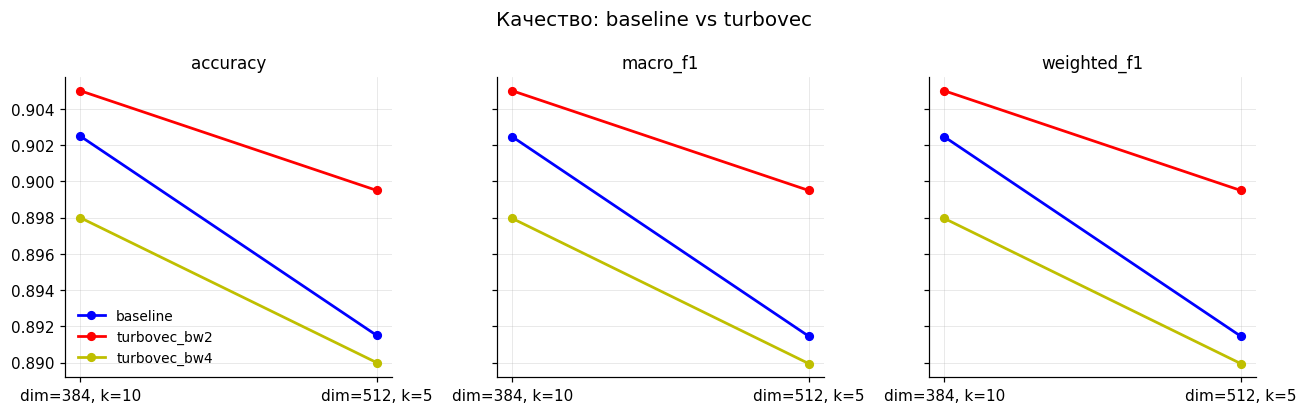

In [9]:
COLORS = {"baseline": "b", "turbovec_bw2": "r", "turbovec_bw4": "y"}
METRIC_COLS = ["accuracy", "macro_f1", "weighted_f1"]

plot_df = metrics_df.sort_values(["dim", "k"]).copy()
plot_df["config"] = "dim=" + plot_df["dim"].astype(str) + ", k=" + plot_df["k"].astype(str)
order = plot_df["config"].drop_duplicates().tolist()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for ax, metric in zip(axes, METRIC_COLS):
    for variant, color in COLORS.items():
        sub = plot_df[plot_df["variant"] == variant].set_index("config").reindex(order)
        ax.plot(order, sub[metric], marker="o", ms=5, lw=1.8, color=color, label=variant)
    ax.set_title(metric, fontsize=11)
    ax.grid(alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Качество: baseline vs turbovec", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Бутстрап доверительных интервалов

In [10]:
def bootstrap_ci(sample, theta_func, alpha=0.05, B=1000, random_state=None, return_samples=False):
    if random_state is not None:
        np.random.seed(random_state)

    N = len(sample)
    theta_estim = theta_func(sample)

    theta_asterisk_array = []
    for _ in range(B):
        bootstrap_sample = np.random.choice(sample, replace=True, size=N)
        theta_asterisk = theta_func(bootstrap_sample)
        theta_asterisk_array.append(theta_asterisk)
    theta_asterisk_array = np.array(theta_asterisk_array)

    left_theta_asterisk, right_theta_asterisk = np.quantile(theta_asterisk_array, [alpha / 2, 1 - alpha / 2])
    left_bound = 2 * theta_estim - right_theta_asterisk
    right_bound = 2 * theta_estim - left_theta_asterisk

    if return_samples:
        return left_bound, right_bound, theta_estim, theta_asterisk_array
    return left_bound, right_bound


def compute_metric_diff_bootstrap(df, run_id, k, bit_width, metric='accuracy', alpha=0.05, B=1000, random_state=42):
    sub = df[(df['k'] == k) & (df['run_id'] == run_id)]
    baseline = sub[sub['variant'] == 'baseline'][['test_id', 'true_label', 'pred_label']]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['test_id', 'true_label', 'pred_label']]
    paired = baseline.merge(tv, on='test_id', suffixes=('_baseline', '_turbovec'))

    y = paired['true_label_baseline'].values
    s_baseline = paired['pred_label_baseline'].values
    s_turbovec = paired['pred_label_turbovec'].values
    metric_fn = (lambda yt, yp: f1_score(yt, yp, average='macro')) if metric == 'f1_macro' else accuracy_score

    def theta_func(idx):
        idx = np.asarray(idx)
        yy = y[idx]
        if len(np.unique(yy)) < 2:
            return np.nan
        return metric_fn(yy, s_turbovec[idx]) - metric_fn(yy, s_baseline[idx])

    sample = np.arange(len(paired))
    ci_low, ci_high, theta_hat, theta_star = bootstrap_ci(
        sample, theta_func, alpha=alpha, B=B, random_state=random_state, return_samples=True
    )

    theta_star_clean = theta_star[~np.isnan(theta_star)]
    if len(theta_star_clean):
        p_emp = min(2 * min((theta_star_clean > 0).mean(), (theta_star_clean < 0).mean()), 1.0)
    else:
        p_emp = np.nan

    return dict(run_id=run_id, k=k, bit_width=bit_width, metric=metric, n=len(paired), n_boot=len(theta_star_clean),
                observed_diff_turbovec_minus_baseline=theta_hat,
                ci95_low=ci_low, ci95_high=ci_high, p_value_empirical=p_emp)

In [11]:
boot_df = pd.DataFrame([
    compute_metric_diff_bootstrap(all_df, run_id, k, bw, metric=metric)
    for (run_id, k), _ in all_df.groupby(["run_id", "k"])
    for bw in (2, 4)
    for metric in ("accuracy", "f1_macro")
])
boot_df["dim"] = boot_df["run_id"].map(lambda r: summaries[r]["dim"])
boot_df.round(5)

,run_id,k,bit_width,metric,n,n_boot,observed_diff_turbovec_minus_baseline,ci95_low,ci95_high,p_value_empirical,dim
0,20260712_124346,10,2,accuracy,2000,1000,0.00250,-0.00600,0.01000,0.464,384
1,20260712_124346,10,2,f1_macro,2000,1000,0.00254,-0.00589,0.01009,0.482,384
2,20260712_124346,10,4,accuracy,2000,1000,-0.00450,-0.00950,0.00050,0.052,384
3,20260712_124346,10,4,f1_macro,2000,1000,-0.00450,-0.00945,0.00049,0.074,384
4,20260712_144747,5,2,accuracy,2000,1000,0.00800,-0.00150,0.01700,0.076,512
5,20260712_144747,5,2,f1_macro,2000,1000,0.00804,-0.00140,0.01700,0.076,512
6,20260712_144747,5,4,accuracy,2000,1000,-0.00150,-0.00650,0.00400,0.468,512
7,20260712_144747,5,4,f1_macro,2000,1000,-0.00151,-0.00652,0.00399,0.518,512


## 5. McNemar тест

In [12]:
def mcnemar_test(df, run_id, k, bit_width):
    sub = df[(df['k'] == k) & (df['run_id'] == run_id)]
    baseline = sub[sub['variant'] == 'baseline'][['test_id', 'true_label', 'pred_label']]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['test_id', 'pred_label']]
    paired = baseline.merge(tv, on='test_id', suffixes=('_baseline', '_turbovec'))

    bl_ok = paired['pred_label_baseline'] == paired['true_label']
    tv_ok = paired['pred_label_turbovec'] == paired['true_label']
    table = [[int((bl_ok & tv_ok).sum()), int((bl_ok & ~tv_ok).sum())],
             [int((~bl_ok & tv_ok).sum()), int((~bl_ok & ~tv_ok).sum())]]

    res = mcnemar(table, exact=False, correction=True)
    return dict(run_id=run_id, k=k, bit_width=bit_width,
                baseline_only_correct=table[0][1], turbovec_only_correct=table[1][0],
                statistic=res.statistic, p_value=res.pvalue)

mcnemar_df = pd.DataFrame([
    mcnemar_test(all_df, run_id, k, bw)
    for (run_id, k), _ in all_df.groupby(["run_id", "k"])
    for bw in (2, 4)
])
mcnemar_df["dim"] = mcnemar_df["run_id"].map(lambda r: summaries[r]["dim"])
mcnemar_df.round(4)

,run_id,k,bit_width,baseline_only_correct,turbovec_only_correct,statistic,p_value,dim
0,20260712_124346,10,2,28,33,0.2623,0.6085,384
1,20260712_124346,10,4,17,8,2.5600,0.1096,384
2,20260712_144747,5,2,37,53,2.5000,0.1138,512
3,20260712_144747,5,4,16,13,0.1379,0.7103,512


## 6. Forest plot

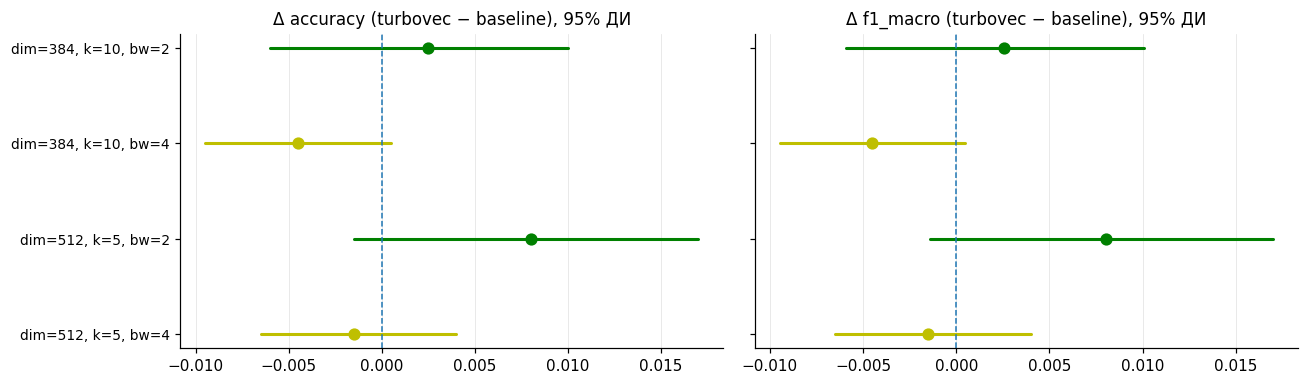

In [13]:
BW_COLORS = {2: "g", 4: "y"}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, metric in zip(axes, ("accuracy", "f1_macro")):
    sub = boot_df[boot_df["metric"] == metric].sort_values(
        ["dim", "k", "bit_width"]).reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    for i, row in sub.iterrows():
        color = BW_COLORS[row["bit_width"]]
        ax.plot([row["ci95_low"], row["ci95_high"]], [ypos[i]] * 2,
                color=color, lw=2, solid_capstyle="round")
        ax.plot(row["observed_diff_turbovec_minus_baseline"], ypos[i], "o", ms=7, color=color)
    ax.axvline(0, lw=1, ls="--")
    labels = ("dim=" + sub["dim"].astype(str) + ", k=" + sub["k"].astype(str)
              + ", bw=" + sub["bit_width"].astype(str))
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f"Δ {metric} (turbovec − baseline), 95% ДИ", fontsize=11)
    ax.grid(axis="x", alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## Вывод

In [14]:
sig_drop_boot = boot_df[boot_df["ci95_high"] < 0]
sig_gain_boot = boot_df[boot_df["ci95_low"] > 0]
sig_drop_mcnemar = mcnemar_df[(mcnemar_df["p_value"] < 0.05) &
                              (mcnemar_df["baseline_only_correct"] > mcnemar_df["turbovec_only_correct"])]

print(f"Bootstrap: значимых просадок (95% CI целиком < 0): {len(sig_drop_boot)} из {len(boot_df)}")
print(f"Bootstrap: значимых улучшений (95% CI целиком > 0): {len(sig_gain_boot)} из {len(boot_df)}")
print(f"McNemar: значимых ухудшений (p < 0.05): {len(sig_drop_mcnemar)} из {len(mcnemar_df)}")
print(f"Худшая наблюдаемая разница: {boot_df['observed_diff_turbovec_minus_baseline'].min():+.4f}")
print(f"Худшая нижняя граница 95% CI: {boot_df['ci95_low'].min():+.4f}")

if len(sig_drop_boot) == 0 and len(sig_drop_mcnemar) == 0:
    print("\nВЕРДИКТ: метрики не просели — turbovec статистически неотличим от baseline.")
else:
    print("\nВЕРДИКТ: обнаружены статистически значимые просадки — см. таблицы выше.")

Bootstrap: значимых просадок (95% CI целиком < 0): 0 из 8
Bootstrap: значимых улучшений (95% CI целиком > 0): 0 из 8
McNemar: значимых ухудшений (p < 0.05): 0 из 4
Худшая наблюдаемая разница: -0.0045
Худшая нижняя граница 95% CI: -0.0095

ВЕРДИКТ: метрики не просели — turbovec статистически неотличим от baseline.


Технология **turbovec не ухудшает качество** бинарной классификации текста.

- По всем 8 сравнениям (2 прогона × bw ∈ {2, 4} × {accuracy, f1 macro}) нет ни одной статистически значимой просадки: все 95% CI разницы накрывают ноль; McNemar тоже не находит значимых различий (min p ≈ 0.11).
- bw=2 численно даже выше baseline в обоих прогонах (+0.0025 и +0.0080).
- bw=4 численно чуть ниже baseline: худшая наблюдаемая разница −0.0045 (dim=384), худшая нижняя граница CI −0.0095 — меньше 1 п.п. На dim=384 разница на грани значимости (эмпирический p ≈ 0.05), при желании стоит перепроверить на большем числе прогонов.

**Proof of concept подтверждён**: turbovec подходит для текстовой классификации, метрики не проседают; bw=2 — безопасный выбор.